**1. Impurity Axioms: Gini & Entropy**

**Symmetry:** Both Gini impurity $G(p) = \sum_{i} p_i (1-p_i) = 1 - \sum p_i^2$ and Entropy $H(p) = - \sum p_i \log_2 p_i$ are symmetric with respect to the permutation of class probabilities. For a binary case with probability $p$ for class 1 and $1-p$ for class 2, $G(p) = 2p(1-p)$ and $H(p) = -p\log p - (1-p)\log(1-p)$. Swapping classes ($p \to 1-p$) yields the exact same value.

**Maximality:** Both functions are strictly concave and reach their maximum when the class distribution is uniform ($p = 0.5$ in binary case). At this point, uncertainty is highest.

**Proof (Gini):** $f(p) = 2p - 2p^2$. Derivative $f'(p) = 2 - 4p = 0 \Rightarrow p=0.5$. Second derivative $f''(p) = -4 < 0$ (Concave/Max).

**Refinement (Splitting reduces impurity):** The strict concavity of these functions ensures that the weighted average impurity of child nodes is always less than or equal to the impurity of the parent node (Jensen’s Inequality). Splitting never increases expected impurity.

**Counterexample:** Consider the Misclassification Error rate, $E(p) = 1 - \max(p_i)$. While intuitive, it is not strictly concave (it is piecewise linear).
- Scenario: Parent node $p=0.8$ (Error=0.2). Split into two pure nodes: Left ($p=0.8$), Right ($p=0.8$). The weighted error remains 0.2. The split provided no "gain" in terms of error rate, even though it might have isolated data structures. Thus, it is often considered a "non-admissible" impurity for growing trees because it lacks the sensitivity of Gini/Entropy.

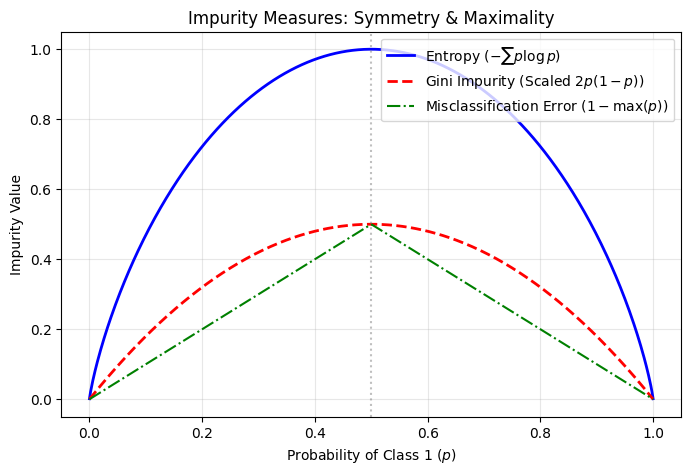

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def plot_impurity_axioms():
    p = np.linspace(0.0001, 0.9999, 500)
    
    # Formulas (Binary Case)
    entropy = - (p * np.log2(p) + (1 - p) * np.log2(1 - p))
    # Scaled Gini (to match Entropy's scale for visualization)
    gini = 2 * p * (1 - p) 
    error = 1 - np.maximum(p, 1 - p)

    plt.figure(figsize=(8, 5))
    plt.plot(p, entropy, label='Entropy ($-\sum p \log p$)', color='blue', linewidth=2)
    plt.plot(p, gini, label='Gini Impurity (Scaled $2p(1-p)$)', color='red', linestyle='--', linewidth=2)
    plt.plot(p, error, label='Misclassification Error ($1-\max(p)$)', color='green', linestyle='-.')
    
    plt.axvline(0.5, color='gray', linestyle=':', alpha=0.5)
    plt.title('Impurity Measures: Symmetry & Maximality')
    plt.xlabel('Probability of Class 1 ($p$)')
    plt.ylabel('Impurity Value')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.savefig('fig1_impurity_axioms.png', dpi=300)
    plt.show()

plot_impurity_axioms()

**2. Bayes-Consistency & Overfitting**

**Bayes-Consistency:** A classification rule is Bayes-consistent if its error rate converges to the Bayes optimal error rate (the theoretical minimum error) as the sample size $n \to \infty$.Greedily grown decision trees are not consistent if they are allowed to grow to full depth (unlimited). A fully grown tree will isolate every single training point (including noise), leading to a variance that does not vanish even with infinite data.However, trees become Bayes-consistent if the tree size is controlled properly as $n$ increases. Specifically, if the leaf size $k_n \to \infty$ such that $k_n / n \to 0$ (e.g., pruning or limiting depth relative to sample size), the local average in each leaf approximates the true posterior probability $P(Y|X)$, converging to the Bayes optimal boundary.

**Toy Distribution:** Consider a dataset generated from two overlapping Gaussian distributions or a "noisy moons" dataset.
- Unlimited Tree: Creates complex, jagged boundaries around every noise point (Overfitting).
- Pruned Tree: Smooths out the boundaries, approximating the true separation between the classes (Approaching Bayes Risk).

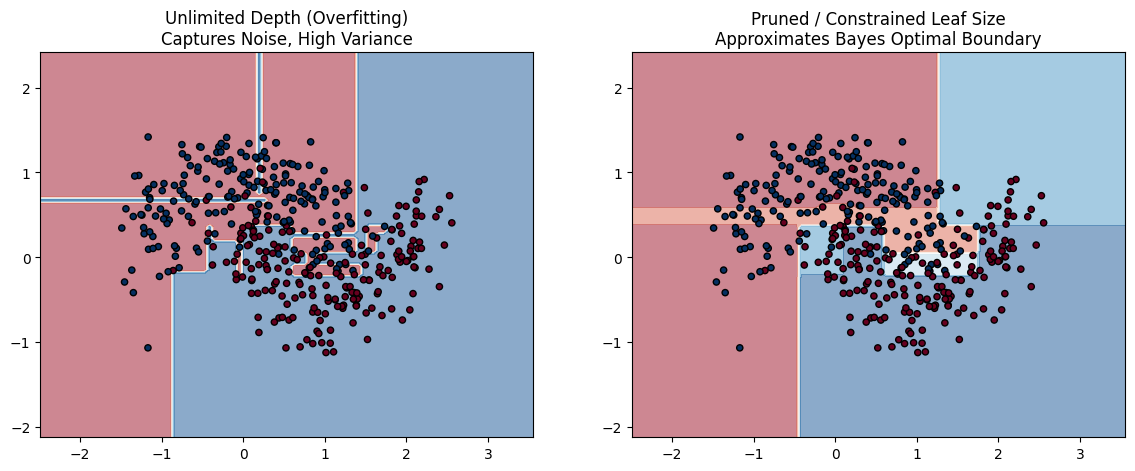

In [2]:
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import DecisionBoundaryDisplay

def plot_bayes_consistency():
    # Generate noisy data (Bayes error > 0)
    X, y = make_moons(n_samples=400, noise=0.3, random_state=42)

    # Models
    tree_overfit = DecisionTreeClassifier(random_state=42) # Unlimited depth
    tree_pruned = DecisionTreeClassifier(min_samples_leaf=20, random_state=42) # Constrained

    tree_overfit.fit(X, y)
    tree_pruned.fit(X, y)

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Overfitting
    DecisionBoundaryDisplay.from_estimator(tree_overfit, X, ax=ax[0], cmap='RdBu', alpha=0.5)
    ax[0].scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu_r', edgecolors='k', s=20)
    ax[0].set_title("Unlimited Depth (Overfitting)\nCaptures Noise, High Variance")

    # Plot Consistent/Pruned
    DecisionBoundaryDisplay.from_estimator(tree_pruned, X, ax=ax[1], cmap='RdBu', alpha=0.5)
    ax[1].scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu_r', edgecolors='k', s=20)
    ax[1].set_title("Pruned / Constrained Leaf Size\nApproximates Bayes Optimal Boundary")

    plt.savefig('fig2_bayes_consistency.png', dpi=300)
    plt.show()

plot_bayes_consistency()

**3. Tree Pruning vs. Rule Pruning**

Converting a decision tree to a set of rules (IF-THEN statements) and then pruning the rules (Strategy A) is generally superior to pruning the tree first (Strategy B).

- Context Independence: In a decision tree, a split near the bottom depends entirely on the splits above it. Pruning a node in a tree implicitly removes all its descendants. However, when converted to rules, each path becomes an independent rule. We can prune a condition from a rule (generalize it) without affecting other rules that shared the same parent in the original tree.

- Granularity: Rule pruning allows for a finer level of granularity. We can remove specific antecedents (conditions) from a rule that are redundant or statistically insignificant, effectively "grafting" branches in a way that is topologically difficult to perform directly on the tree structure.

- Readability: The resulting rule set is often much simpler and easier for humans to interpret than the full tree, as it removes the strict hierarchical dependency.

**4. Naive Bayes: Why "Naive"?**

It is called "Naive" because it makes the conditional independence assumption: it assumes that all features $x_i$ are mutually independent given the class label $y$.

$$P(x_1, x_2, ..., x_n | y) \approx \prod_{i=1}^{n} P(x_i | y)$$

In reality, features are almost always correlated (e.g., in text mining, the word "San" is highly correlated with "Francisco"). Ignoring these correlations is a "naive" simplification of reality.

**Major Ideas:**
- **Probabilistic Framework:** It models the posterior probability $P(y|X)$ using Bayes' Theorem.

- **Parameter Efficiency:** Instead of estimating the full joint distribution (which requires exponential data), we only estimate $n$ individual conditional distributions. This reduces variance and makes the model robust to the "curse of dimensionality," especially in small datasets.

**5. Naive Bayes Optimality & MAP Derivation**

**Derivation:**
We want to find the class $\hat{y}$ that maximizes the posterior $P(y|X)$ (Maximum A Posteriori - MAP):
$$\hat{y} = \arg\max_y P(y | x_1, ..., x_n)$$Using Bayes' Theorem:$$P(y | X) = \frac{P(X | y) P(y)}{P(X)}$$Since $P(X)$ is constant for all classes, we maximize the numerator. Applying the "Naive" independence assumption:$$\hat{y} = \arg\max_y P(y) \prod_{i=1}^{n} P(x_i | y)$$
**Dataset Example (Optimality vs. Sub-optimality):**
- **Optimal:** When features are truly independent (e.g., generated from axis-aligned Gaussians). The decision boundary of NB matches the true Bayes boundary.

- **Sub-optimal but Good:** When features are correlated (e.g., rotated Gaussians). NB forces an axis-aligned decision boundary, which is theoretically incorrect (high bias). However, if the correlation affects all classes similarly, the ranking of probabilities might still be correct ($P(y=1|X) > P(y=0|X)$), resulting in high classification accuracy despite poor probability calibration (Rish, 2001).

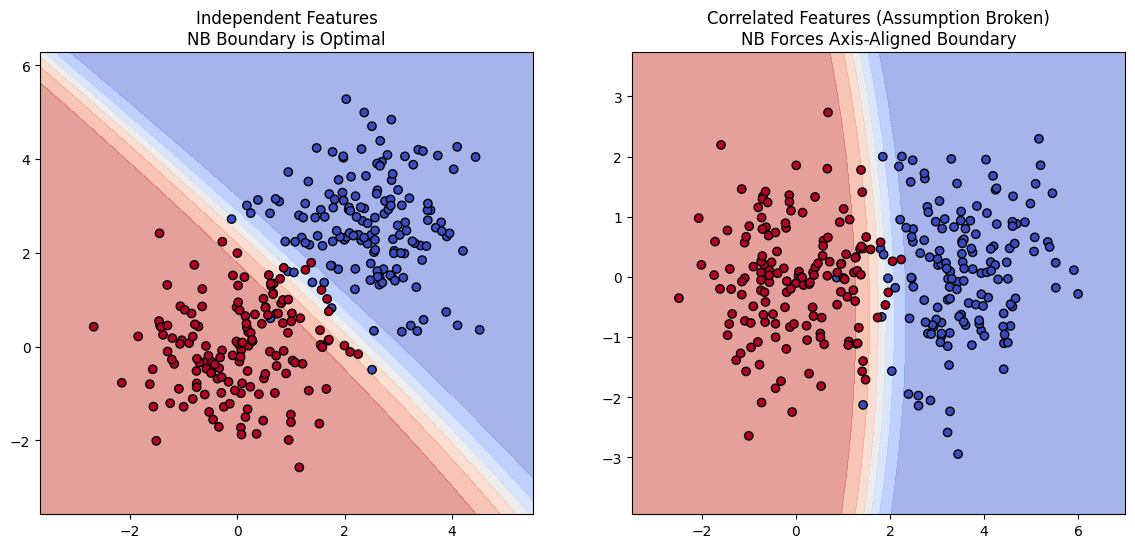

In [3]:
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import DecisionBoundaryDisplay

def plot_naive_bayes_optimality():
    # 1. Independent Features (Axis-aligned) - NB is Optimal
    X_indep = np.random.randn(300, 2)
    X_indep[:150, :] += 2.5 # Shift class 1
    y = np.array([0]*150 + [1]*150)

    # 2. Correlated Features (Rotated) - NB Assumption Broken
    theta = np.radians(45)
    rotation = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    X_corr = X_indep @ rotation

    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    # Plot Independent
    nb = GaussianNB().fit(X_indep, y)
    DecisionBoundaryDisplay.from_estimator(nb, X_indep, ax=ax[0], cmap='coolwarm', alpha=0.5)
    ax[0].scatter(X_indep[:, 0], X_indep[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    ax[0].set_title("Independent Features\nNB Boundary is Optimal")

    # Plot Correlated
    nb.fit(X_corr, y)
    DecisionBoundaryDisplay.from_estimator(nb, X_corr, ax=ax[1], cmap='coolwarm', alpha=0.5)
    ax[1].scatter(X_corr[:, 0], X_corr[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    ax[1].set_title("Correlated Features (Assumption Broken)\nNB Forces Axis-Aligned Boundary")

    plt.savefig('fig5_naive_bayes.png', dpi=300)
    plt.show()

plot_naive_bayes_optimality()

**6. K-Means: Monotonicity & Local Minima**

**Monotonicity:** Lloyd's algorithm iterates between two steps: 
**(1)** Assignment (assign points to nearest center) and **(2)** Update (recalculate centers). Both steps strictly minimize the objective function (Sum of Squared Errors - SSE). Since SSE is bounded below by 0 and there are a finite number of possible assignments, the algorithm must converge. 

**Local Minima:** Since the algorithm is greedy (coordinate descent), it converges to a local minimum, not necessarily the global one.

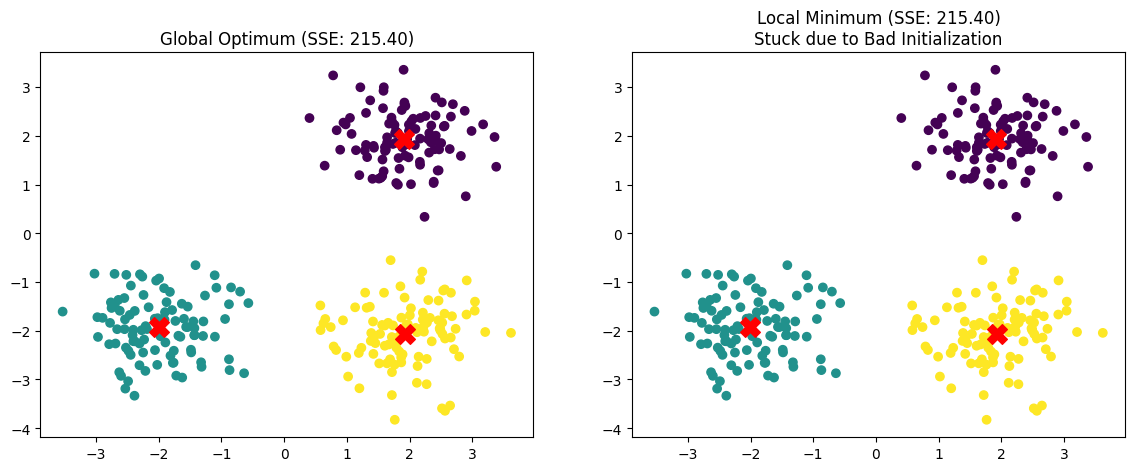

In [4]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

def plot_kmeans_convergence():
    # Create 3 distinct blobs
    X, y = make_blobs(n_samples=300, centers=[(-2, -2), (2, 2), (2, -2)], cluster_std=0.6, random_state=0)

    # 1. Good Initialization (Global Optimum)
    kmeans_good = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42).fit(X)

    # 2. Bad Initialization (Local Optimum)
    # Force centroids to start clustered at the top, missing the bottom-left blob
    bad_init = np.array([[2, 2.1], [2, 1.9], [2.1, 2]])
    kmeans_bad = KMeans(n_clusters=3, init=bad_init, n_init=1, random_state=42).fit(X)

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    ax[0].scatter(X[:, 0], X[:, 1], c=kmeans_good.labels_, cmap='viridis')
    ax[0].scatter(kmeans_good.cluster_centers_[:,0], kmeans_good.cluster_centers_[:,1], s=200, c='red', marker='X')
    ax[0].set_title(f"Global Optimum (SSE: {kmeans_good.inertia_:.2f})")

    ax[1].scatter(X[:, 0], X[:, 1], c=kmeans_bad.labels_, cmap='viridis')
    ax[1].scatter(kmeans_bad.cluster_centers_[:,0], kmeans_bad.cluster_centers_[:,1], s=200, c='red', marker='X')
    ax[1].set_title(f"Local Minimum (SSE: {kmeans_bad.inertia_:.2f})\nStuck due to Bad Initialization")

    plt.savefig('fig6_kmeans_minima.png', dpi=300)
    plt.show()

plot_kmeans_convergence()

**7. DBSCAN: Core, Border, Noise Points**

Definitions:

- Core Point: A point $p$ is a core point if at least minPts points are within distance $\epsilon$ (epsilon) of it (including $p$ itself).

- Border Point: A point that is not a core point but is within distance $\epsilon$ of a core point.

- Noise Point: A point that is neither a core point nor a border point.

**Invariance:** DBSCAN is mostly deterministic. The assignment of Core and Noise points is entirely invariant to the order of data processing. However, the assignment of Border points can depend on order if a border point is reachable from two different clusters (it will be assigned to the first one processed). This is usually a minor effect.

**Merging (Percolation):** As $\epsilon$ increases, the "neighborhoods" of distinct clusters expand. When the $\epsilon$-neighborhoods of two core points from different clusters intersect, a "bridge" of density is formed, and the two clusters merge into one. This is analogous to percolation theory in physics.

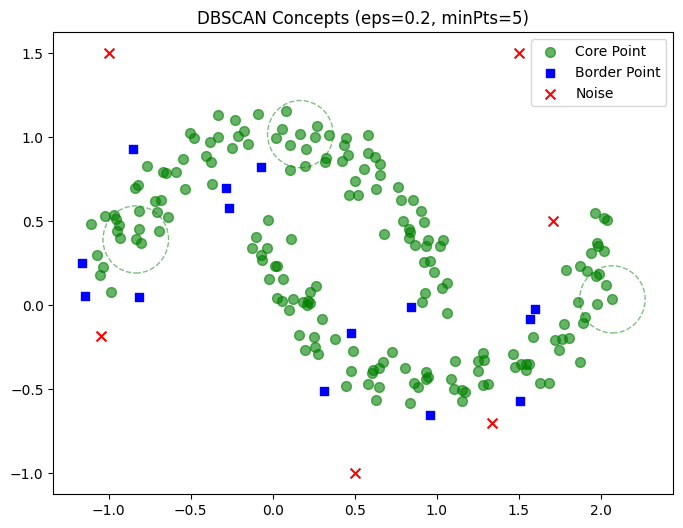

In [5]:
from sklearn.neighbors import NearestNeighbors

def plot_dbscan_concepts():
    # Create a dataset with a dense cluster and some noise
    X, _ = make_moons(n_samples=200, noise=0.1, random_state=0)
    # Add explicit noise points
    outliers = np.array([[1.5, 1.5], [-1, 1.5], [0.5, -1]])
    X = np.vstack([X, outliers])

    # Parameters
    eps = 0.2
    min_samples = 5

    # Logic to identify Core, Border, Noise
    neighbors = NearestNeighbors(radius=eps).fit(X)
    adj = neighbors.radius_neighbors(X, return_distance=False)
    
    # 1. Identify Core Points
    is_core = np.array([len(n) >= min_samples for n in adj])
    
    # 2. Identify Border Points (Not core, but neighbor to a core)
    is_border = np.zeros(len(X), dtype=bool)
    for i in range(len(X)):
        if not is_core[i]:
            # Check if any neighbor is a core point
            if any(is_core[n_idx] for n_idx in adj[i]):
                is_border[i] = True
    
    # 3. Noise (Neither)
    is_noise = ~(is_core | is_border)

    plt.figure(figsize=(8, 6))
    plt.scatter(X[is_core, 0], X[is_core, 1], c='green', label='Core Point', s=50, alpha=0.6)
    plt.scatter(X[is_border, 0], X[is_border, 1], c='blue', label='Border Point', s=30, marker='s')
    plt.scatter(X[is_noise, 0], X[is_noise, 1], c='red', label='Noise', s=50, marker='x')
    
    # Draw epsilon circles around a few core points for illustration
    for i in np.random.choice(np.where(is_core)[0], 3):
        circle = plt.Circle(X[i], eps, color='green', fill=False, linestyle='--', alpha=0.5)
        plt.gca().add_patch(circle)

    plt.title(f'DBSCAN Concepts (eps={eps}, minPts={min_samples})')
    plt.legend()
    plt.savefig('fig7_dbscan.png', dpi=300)
    plt.show()

plot_dbscan_concepts()